# Fit IV data

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('../vPDU_analysis/')
sys.path.append("../vPDU_reco-ana/veto_passport/AnalysisTools")
from IV_curves import load_data, load_setup
#from IV_Analysis import plot_group
import IVAnalysis as IVAnalysis

## ----- INPUTS -----

In [2]:
# ---- INPUTS ----
batch = 2 #1, 2
temperature = 'warm' #warm, cold
layer = 'top' #top, bottom
configuration = 'tiles' #quadrants, tiles
date = '23052025' #ddmmyyyy
time_step = '3' #s
save = True

In [3]:
vpdusQR = load_setup(f'Batch_{batch}/setup/vpdu_{layer}.json')

#SET PATHS
file_path = f'Batch_{batch}/{temperature}_tests/Data/IV/splitted/'

✅ Q1: Vbd = 66.60 V ± 6.66
✅ Q2: Vbd = 66.60 V ± 6.66
✅ Q3: Vbd = 66.60 V ± 6.66
✅ Q4: Vbd = 66.60 V ± 6.66


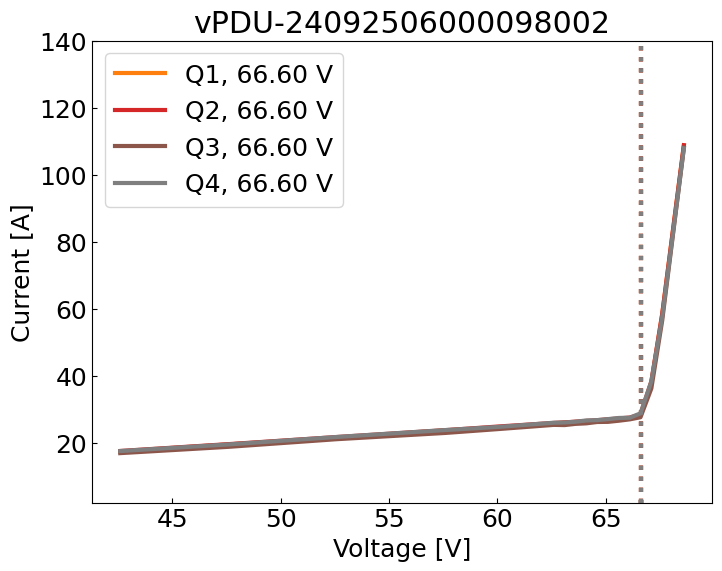

✅ Q5: Vbd = 66.60 V ± 6.66
✅ Q6: Vbd = 66.60 V ± 6.66
❌ Fitting failed for ColdTileIV7: index -1 is out of bounds for axis 0 with size 0
✅ Q8: Vbd = 66.60 V ± 6.66


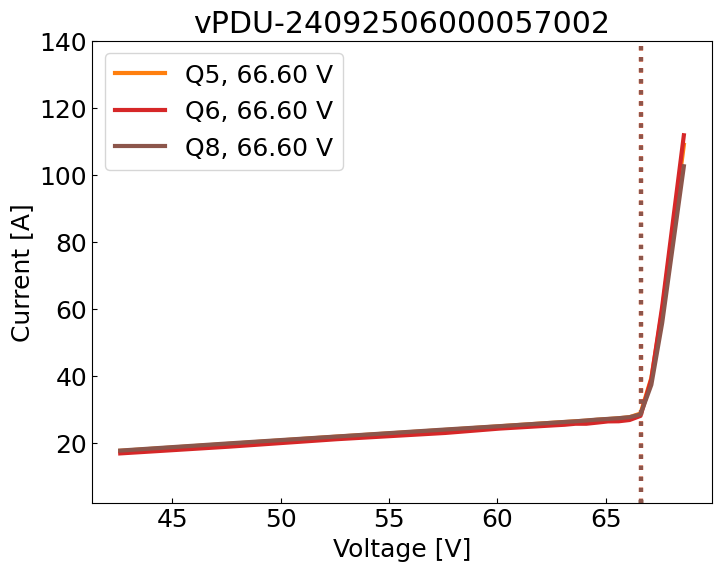

✅ Q9: Vbd = 66.60 V ± 6.66
✅ Q10: Vbd = 66.60 V ± 6.66
✅ Q11: Vbd = 66.60 V ± 6.66
❌ Fitting failed for ColdTileIV12: index -1 is out of bounds for axis 0 with size 0


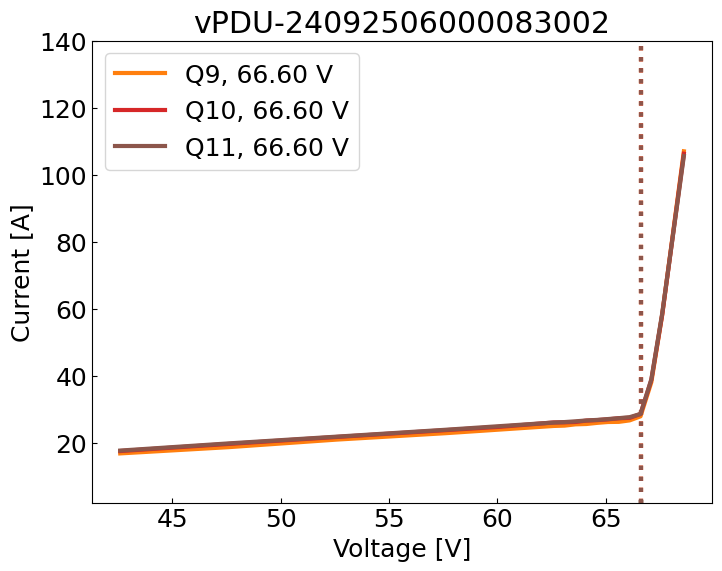

In [4]:

base_path = file_path

file = [os.path.join(base_path, f"IV_q{i}.txt") for i in range(12)]

IV = IVAnalysis.IVAnalysis()
Vbd_Cold = [None] * 12
Vbd_cold_err = [None] * 12

def plot_group(file_indices, title, Vlim = [15, 80]):
    
    IV = IVAnalysis.IVAnalysis()
    Vbd_Cold = [None] * 4
    Vbd_cold_err = [None] * 4

    plt.figure(figsize=[8, 6])
    for idx in file_indices:
        try:
            Vbd, Vbd_err = IV.calc_Vbd(file[idx], Vstart=Vlim[0], Vstop=Vlim[1], plot_opt=True)
            IV.plot_tileIV(file[idx], label=f"Q{idx+1}, {Vbd:.2f} V")
            line = plt.gca().lines[-1]
            plt.axvline(Vbd, color=line.get_color(), linestyle=':', linewidth=3)
            print(f"✅ Q{idx+1}: Vbd = {Vbd:.2f} V ± {Vbd_err:.2f}")
        except Exception as e:
            print(f"❌ Fitting failed for ColdTileIV{idx+1}: {e}")
            continue
    plt.xlabel("Voltage [V]")
    plt.ylabel("Current [A]")
    plt.title(title)
    #plt.xlim(45, 64)
    plt.ylim(2.3, 140)
    #plt.legend()
    plt.show()
    

plt.rcParams.update({'font.size': 18}) 
plt.rcParams.update({'lines.linewidth': 3}) 
plt.rcParams.update({'xtick.direction': 'in'}) 
plt.rcParams.update({'ytick.direction': 'in'})

# Plot files 0 to 3 in one figure
plot_group([0,1,2,3], title="vPDU-24092506000098002")
plot_group([4,5,6,7], title="vPDU-24092506000057002")
plot_group([8,9,10,11], title="vPDU-24092506000083002")